# Portfolio Analyzer Tool Test

This notebook tests the new `PortfolioAnalyzer` class by:
1. Running multiple backtests with different strategies/parameters.
2. Combining the `BacktestResult` objects into a weighted portfolio.
3. Calculating and displaying portfolio-level and diversification-specific metrics.
4. Visualizing the combined equity curve and correlation matrix.

In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sysstrat import (
    load_simple_price_csv,
    FixedRiskPositionStrategy,
    PortfolioAnalyzer,
    BuyAndHoldStrategy,
    VectorizedEngine,
    plot_results,
    plot_backtest_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-07-29 12:43:41.216 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-07-29 12:43:41.246 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


## 2. Run Multiple Backtests

We will run 3 different strategies to create a diverse set of `BacktestResult` objects.

In [4]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 252
RISK_TARGET = 0.2
MULTIPLIER=1.0
MAX_LEVERAGE=1.0
COMMISSION_RATE=0.0005
SLIPPAGE_RATE=0.0005

In [5]:
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=COMMISSION_RATE,
    slippage_rate=SLIPPAGE_RATE
)

In [6]:
strategy1 = FixedRiskPositionStrategy(volatility_window=21, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)
strategy2 = FixedRiskPositionStrategy(volatility_window=63, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)
strategy3 = FixedRiskPositionStrategy(volatility_window=252, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)

In [7]:
result1 = engine.run(strategy1, data)
result2 = engine.run(strategy2, data)
result3 = engine.run(strategy3, data)

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


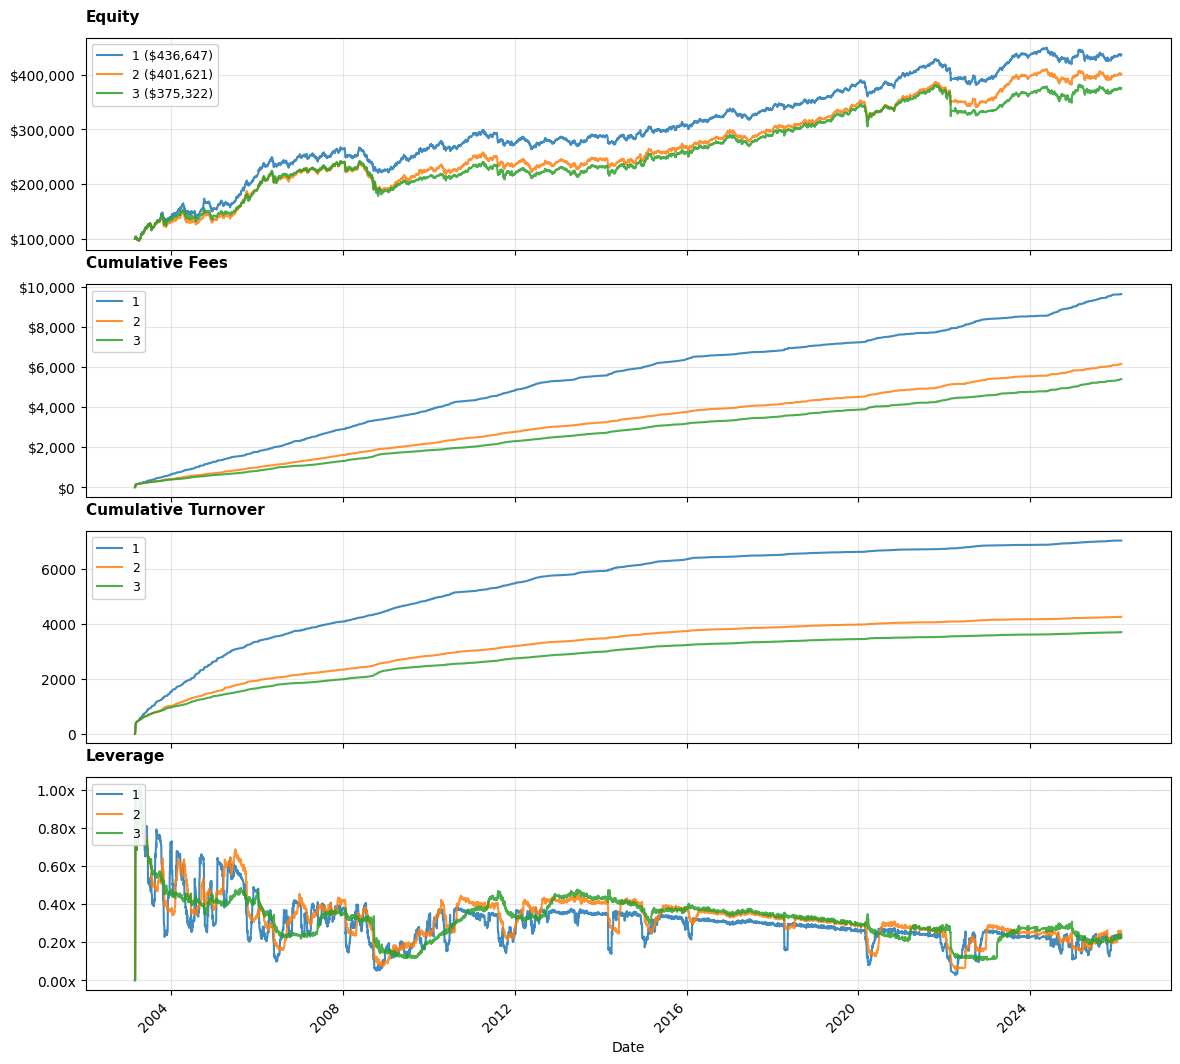

In [8]:
plot_backtest_results(
    results={"1": result1, "2": result2, "3": result3},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage'],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

In [9]:
results = []
results.append(result1)
results.append(result2)
results.append(result3)

## 3. Initialize Portfolio Analyzer

We will combine the 3 backtest results. Let's assign custom weights (e.g., 40% to the fast MA, 30% to slow MA, 30% to SMA crossover) and use a 7% annual risk-free rate.

In [10]:
portfolio_weights = [0.4, 0.3, 0.3]
risk_free_rate = 0.07  # 7% annual

# Initialize the analyzer
analyzer = PortfolioAnalyzer(
    strategies=results,
    names=["1", "2", "3"],
    weights=portfolio_weights,
    risk_free_rate=risk_free_rate,
    trading_days_per_year=252
)

print("✅ PortfolioAnalyzer initialized successfully.")

✅ PortfolioAnalyzer initialized successfully.


In [13]:
result = analyzer.run()

## 4. View Portfolio & Diversification Metrics

This will print a formatted summary showing how combining these strategies affects overall risk and return.

In [14]:
result.print_summary()


════════════════════════════════════════════════════════════════════════════════
 PORTFOLIO ANALYSIS SUMMARY
════════════════════════════════════════════════════════════════════════════════

Strategy Allocation:
  1                             :   40.0%
  2                             :   30.0%
  3                             :   30.0%

────────────────────────────────────────────────────────────────────────────────
Portfolio Performance Metrics:
────────────────────────────────────────────────────────────────────────────────
  Total Return                                    +308.03%
  CAGR                                              +6.37%
  Annual Volatility                                  8.36%
  Sharpe Ratio                                       -0.08
  Sortino Ratio                                      -0.09
  Max Drawdown                                     -21.87%
  Gross Sharpe                                        0.77
  Fee Drag Ratio                                      

## 5. Detailed Diversification Analysis

Let's extract and examine the specific diversification metrics to understand *why* the portfolio behaves the way it does.

In [16]:
div_metrics = result.get_diversification_metrics()

print("🔍 DEEP DIVE: Diversification Metrics")
print("-" * 50)
print(f"Diversification Ratio: {div_metrics['diversification_ratio']:.2f}")
print("  ↳ > 1.0 indicates that combining strategies reduced overall portfolio risk.")
print(f"\nVolatility Reduction: {div_metrics['volatility_reduction_pct']:.1f}%")
print("  ↳ Percentage of risk eliminated compared to holding strategies in isolation.")
print(f"\nAverage Correlation: {div_metrics['avg_correlation']:.2f}")
print("  ↳ Lower is better for diversification. 1.0 means they move perfectly together.")
print("\nIndividual Strategy Volatilities:")
for name, vol in div_metrics['individual_vols_pct'].items():
    print(f"  - {name}: {vol:.1f}%")
print(f"  - Portfolio: {div_metrics['portfolio_vol_pct']:.1f}%")

🔍 DEEP DIVE: Diversification Metrics
--------------------------------------------------
Diversification Ratio: 1.01
  ↳ > 1.0 indicates that combining strategies reduced overall portfolio risk.

Volatility Reduction: 1.4%
  ↳ Percentage of risk eliminated compared to holding strategies in isolation.

Average Correlation: 0.96
  ↳ Lower is better for diversification. 1.0 means they move perfectly together.

Individual Strategy Volatilities:
  - 1: 7.8%
  - 2: 8.7%
  - 3: 9.1%
  - Portfolio: 8.4%


## 6. Correlation Matrix

Visualizing the pairwise correlation of daily returns between the strategies.

In [18]:
corr_matrix = result.correlation_matrix

# Style the dataframe for better readability in Jupyter
styled_corr = corr_matrix.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format("{:.2f}")
styled_corr

,1,2,3
1,1.00,0.97,0.93
2,0.97,1.00,0.97
3,0.93,0.97,1.00


In [19]:
portfolio_as_backtest = result.to_backtest_result(name="Diversified Portfolio")

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


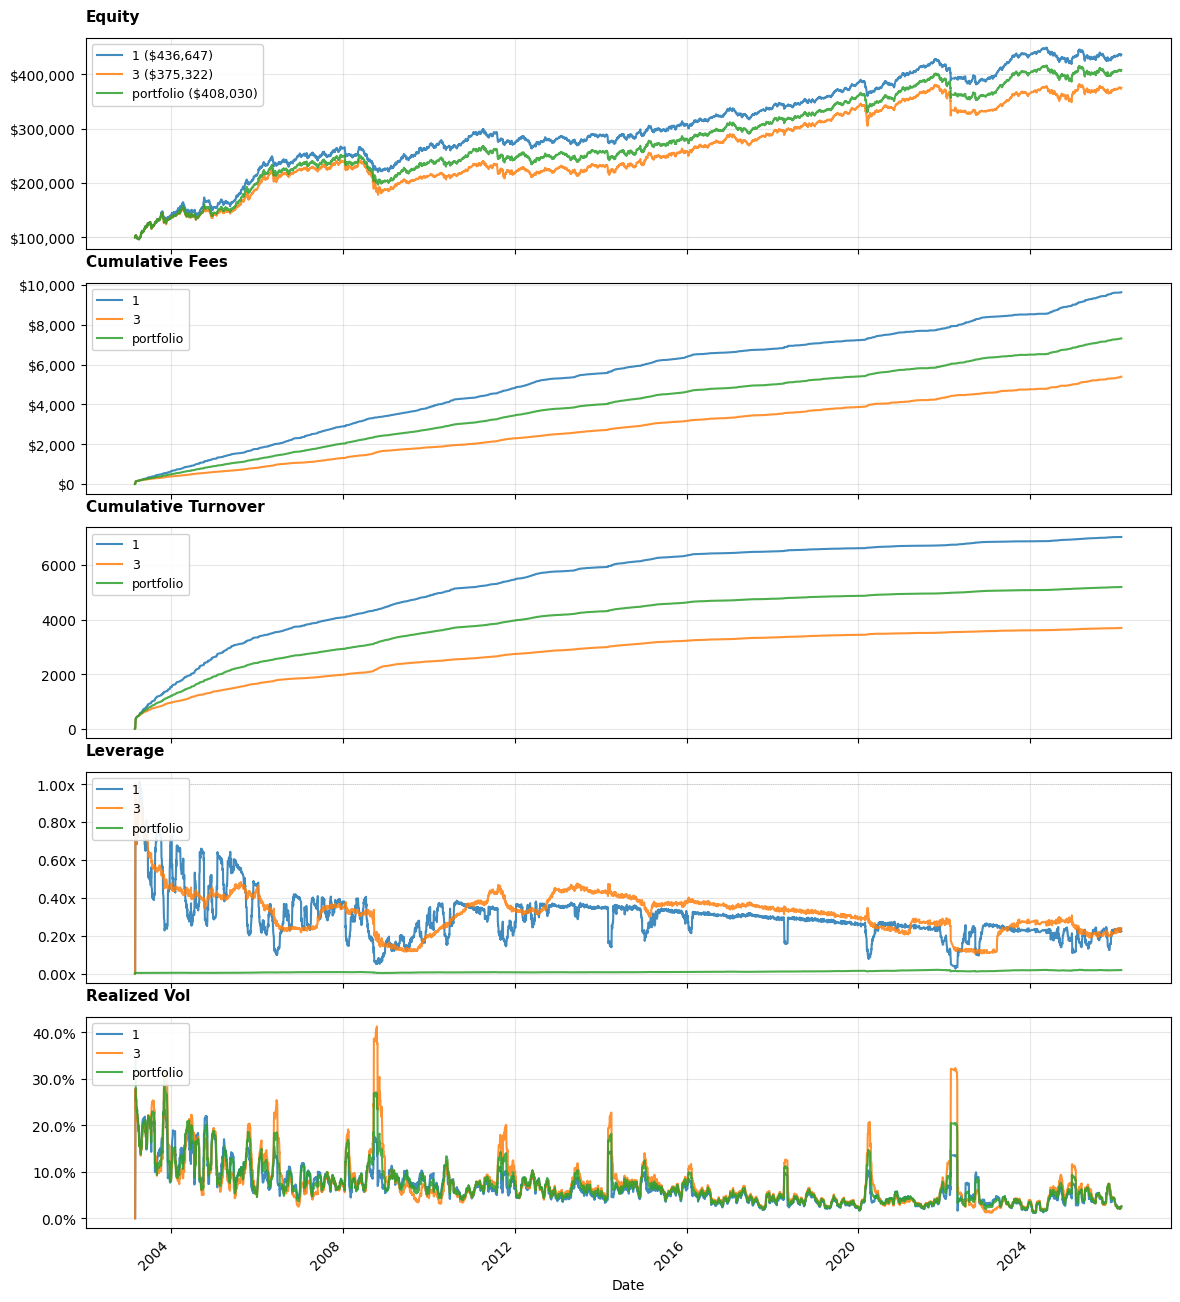

In [21]:
plot_backtest_results(
    results={"1": result1, "3": result3, "portfolio": portfolio_as_backtest},
    panels=['equity', 'cumulative_fees', 'cumulative_turnover', 'leverage', 'realized_vol'],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)